In [1]:
from pathlib import Path
from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE
import gc
import torch
import pandas as pd
from tqdm import tqdm
import shutil

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/tsr_samples_tester_new")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_samples_tester_new")

REPLICA_EXCHANGE = True
LAM_VALUES = LAM_VALUES
INDEX_UNTIL = 6


gc.collect()
torch.cuda.empty_cache()

if PT_TSR_DIR.exists():
    shutil.rmtree(PT_TSR_DIR)

In [2]:
# ── Load prompts once ─────────────────────────────────────────────────────────
prompts = pd.read_csv(PROMPTS_FILE, usecols=["text"], nrows=INDEX_UNTIL)["text"].tolist()
print(f"Loaded {len(prompts)} prompts")

from diffusers import StableDiffusion3Pipeline

# ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

replica_exchanges = [False, True]

lam_dirs = {}
for re in replica_exchanges:
	base = PT_TSR_DIR if re else TSR_DIR
	lam_dirs[re] = {l: base / f"lam{l:.3f}".replace(".", "p") for l in LAM_VALUES}
	for d in lam_dirs[re].values():
		d.mkdir(parents=True, exist_ok=True)

# ── Sweep ─────────────────────────────────────────────────────────────────────
for idx, prompt in enumerate(prompts):
	
	for replica_exchange in replica_exchanges:
	
		for tsr_lam in tqdm(LAM_VALUES, desc=f"idx={idx} re={replica_exchange}"):

			output_dir = lam_dirs[replica_exchange][tsr_lam]

			if (output_dir / f"{idx:05d}.png").exists():
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{idx:05d}.png"
			images[0].save(out_path, icc_profile=None)
			del images
		torch.cuda.empty_cache()

print("\n All k values complete.")

Loaded 6 prompts


Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

 We tsr by 1.01 with replica exchange True
Time 763.76 swap btwn source 1.00 and target 1.01 accept 1.000 std 0.797
Time 738.04 swap btwn source 0.99 and target 1.00 accept 1.000 std 0.786
Time 648.86 swap btwn source 1.00 and target 1.01 accept 1.000 std 0.767
Time 614.30 swap btwn source 0.99 and target 1.00 accept 1.000 std 0.767
Time 491.46 swap btwn source 1.00 and target 1.01 accept 0.999 std 0.803
Time 442.58 swap btwn source 0.99 and target 1.00 accept 0.999 std 0.833


idx=5 re=True:  67%|██████▋   | 2/3 [01:06<00:33, 33.42s/it]

 We tsr by 1.05 with replica exchange True
Time 763.76 swap btwn source 1.00 and target 1.05 accept 0.999 std 0.797
Time 738.04 swap btwn source 0.95 and target 1.00 accept 0.997 std 0.786
Time 648.86 swap btwn source 1.00 and target 1.05 accept 0.997 std 0.763
Time 614.30 swap btwn source 0.95 and target 1.00 accept 0.997 std 0.761
Time 491.46 swap btwn source 1.00 and target 1.05 accept 0.996 std 0.789
Time 442.58 swap btwn source 0.95 and target 1.00 accept 0.992 std 0.813


idx=5 re=True: 100%|██████████| 3/3 [01:40<00:00, 33.48s/it]


 All k values complete.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


Real features computed from 6 images.


── lam1p100 ──


...

[False]  lam=1.010  FID=242.9951  CLIP=30.8272

── lam1p050 ──


CLIP lam=1.05: 100%|██████████| 6/6 [00:00<00:00, 21.33it/s]


[True]  lam=1.050  FID=230.5423  CLIP=31.2098


CLIP lam=1.05: 100%|██████████| 6/6 [00:00<00:00, 21.83it/s]


[False]  lam=1.050  FID=238.3663  CLIP=31.3299


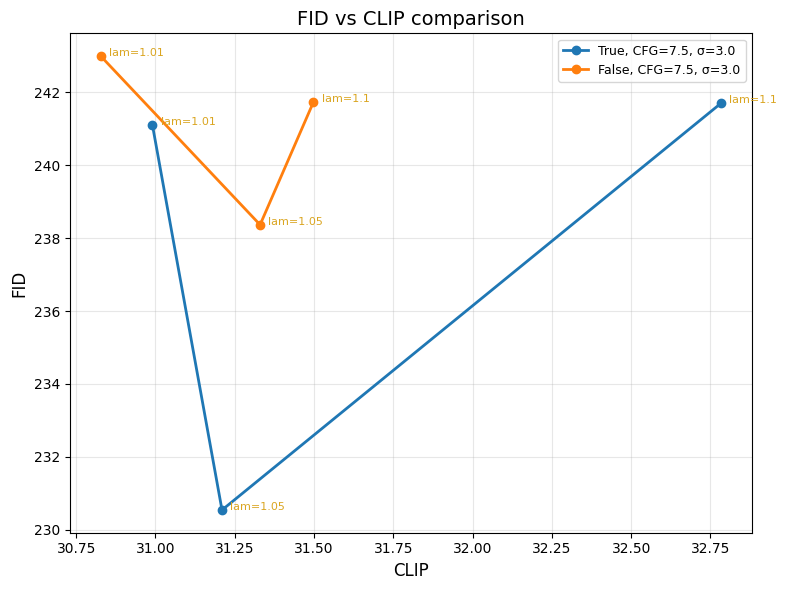

{True: {1.1: (np.float64(241.69943887200193), np.float64(32.7832457224528)),
  1.01: (np.float64(241.10730357089017), np.float64(30.99032974243164)),
  1.05: (np.float64(230.5422991771855), np.float64(31.209800720214844))},
 False: {1.1: (np.float64(241.72518142386525), np.float64(31.49780527750651)),
  1.01: (np.float64(242.99509215011705), np.float64(30.827167510986328)),
  1.05: (np.float64(238.36630481883788), np.float64(31.329885800679524))}}

In [3]:
from fid import compute_sweep

compute_sweep(
	lam_values=LAM_VALUES,
	replica_exchanges=[True, False],
	device="cuda",
	target_indices=None,
	index_until=INDEX_UNTIL,
	tsr_dir = TSR_DIR,
	pt_sr_dir = PT_TSR_DIR,
)